# 2. O Método das Isóclinas

Considere uma EDO de primeira ordem
$$
y'=f(x,y).
$$
Em cada ponto $(x,y)$ onde $f$ está definida, a equação determina a inclinação $y'=f(x,y)$ da tangente à curva integral.

Assim, uma EDO define geometricamente um **campo de direções**. Nesta seção estudaremos como as **isóclinas** organizam esse campo e permitem obter informações qualitativas sobre as soluções antes de integrarmos a equação.

## 2.1 Campo de direções

Para
$$
y'=f(x,y),
$$
associamos ao ponto $(x,y)$ um pequeno segmento de reta de coeficiente angular
$$
m=f(x,y).
$$
O conjunto desses segmentos constitui o **campo de direções**.

O problema de determinar uma curva integral pode ser interpretado geometricamente:

> Procuramos uma curva cuja reta tangente, em cada ponto, tenha a direção prescrita pelo campo.

A equação fornece informação **local**; uma solução é uma curva **global** compatível com essas direções.

### Exemplo: $$ y'= 2x-y $$

No ponto $(0,0)$, $y'=0$. No ponto $(1,0)$, $y'=2$. No ponto $(0,1)$, $y'=-1$.

Vamos visualizar o campo.

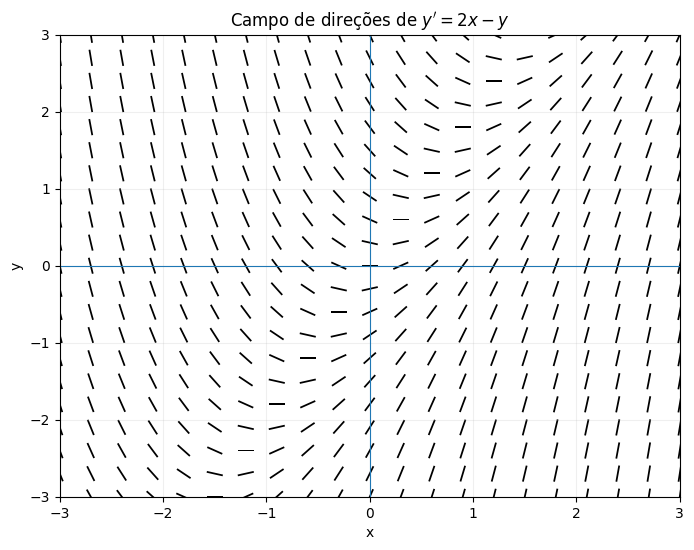

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def campo_direcoes(f, xlim=(-3,3), ylim=(-3,3), nx=21, ny=21):
    x = np.linspace(*xlim, nx)
    y = np.linspace(*ylim, ny)
    X, Y = np.meshgrid(x, y)
    M = f(X,Y)
    U = 1/np.sqrt(1+M**2)
    V = M/np.sqrt(1+M**2)
    plt.figure(figsize=(8,6))
    plt.quiver(X,Y,U,V,angles='xy',pivot='mid',
               headwidth=0,headlength=0,headaxislength=0)
    plt.axhline(0,linewidth=.8)
    plt.axvline(0,linewidth=.8)
    plt.xlim(xlim); plt.ylim(ylim)
    plt.xlabel("x"); plt.ylabel("y")
    plt.grid(alpha=.2)

f = lambda x,y: 2*x-y
campo_direcoes(f)
plt.title(r"Campo de direções de $y'=2x-y$")
plt.show()

O gráfico representa esquematicamente a função
$$
(x,y)\longmapsto f(x,y).
$$
As curvas integrais devem acompanhar essas direções.

### Como o campo de direções é construído?

A parte matematicamente essencial do código é

```python
M = f(X,Y)
U = 1/np.sqrt(1+M**2)
V = M/np.sqrt(1+M**2)
```

Para uma equação diferencial

$$
y'=f(x,y),
$$

a inclinação da curva integral no ponto $(x,y)$ é $f(x,y)$.

Uma direção com essa inclinação pode ser representada pelo vetor

$$
(1,f(x,y)).
$$

Para que todos os segmentos desenhados tenham o mesmo comprimento, normalizamos esse vetor. Como

$$
\|(1,f(x,y))\|
=
\sqrt{1+f(x,y)^2},
$$

obtemos o vetor unitário

$$
\boxed{
(U,V)
=
\frac{(1,f(x,y))}
{\sqrt{1+f(x,y)^2}}
}.
$$

**Por que esse vetor continua tendo a inclinação correta?**

A inclinação de um vetor $(U,V)$ é dada pela razão entre sua componente vertical e sua componente horizontal. Portanto,

$$
\frac{V}{U}
=
\frac{
f(x,y)/\sqrt{1+f(x,y)^2}
}{
1/\sqrt{1+f(x,y)^2}
}
=
f(x,y).
$$

Portanto, **normalizar o vetor muda seu comprimento, mas não muda sua inclinação**.

Dessa forma, todos os segmentos do campo podem ser desenhados com o mesmo comprimento, preservando exatamente as direções determinadas pela EDO.

---

### Como o código funciona?

Os comandos

```python
x = np.linspace(*xlim, nx)
y = np.linspace(*ylim, ny)
```

criam os pontos dos eixos $x$ e $y$ nos quais o campo será representado.

Por exemplo, se

```python
xlim = (-3,3)
nx = 21
```

então `np.linspace(*xlim, nx)` produz $21$ valores igualmente espaçados entre $-3$ e $3$.

O símbolo `*` em `*xlim` "desempacota" a tupla `(-3,3)`. Assim,

```python
np.linspace(*xlim, nx)
```

é equivalente a

```python
np.linspace(-3, 3, 21)
```

---

A instrução

```python
X, Y = np.meshgrid(x, y)
```

constrói uma **malha de pontos $(x,y)$ no plano**.

Dessa forma, em vez de trabalharmos apenas com uma lista de valores de $x$ e uma lista de valores de $y$, passamos a trabalhar com todas as combinações

$$
(x_i,y_j).
$$

Esses serão os pontos nos quais calcularemos as inclinações do campo.

---

A instrução

```python
M = f(X,Y)
```

calcula a inclinação determinada pela equação diferencial em cada ponto da malha.

Como

$$
y'=f(x,y),
$$

temos

$$
M=f(X,Y).
$$

Assim, cada elemento de `M` contém o valor de $y'$ no ponto correspondente.

Por exemplo, para

$$
y'=2x-y,
$$

temos

```python
f = lambda x, y: 2*x - y
```

e, portanto,

$$
M=2X-Y.
$$

---

As instruções

```python
U = 1/np.sqrt(1+M**2)
V = M/np.sqrt(1+M**2)
```

constroem, em cada ponto, o vetor unitário

$$
(U,V)
=
\frac{(1,M)}{\sqrt{1+M^2}}.
$$

Como $M=f(x,y)$, esse vetor possui exatamente a inclinação prescrita pela equação diferencial.

A normalização garante que segmentos correspondentes a inclinações muito grandes não sejam desenhados maiores que aqueles correspondentes a inclinações pequenas.

---

A instrução

```python
plt.quiver(X,Y,U,V,angles='xy',pivot='mid',
           headwidth=0,headlength=0,headaxislength=0)
```

desenha, em cada ponto $(X,Y)$ da malha, o vetor $(U,V)$.

A opção

```python
pivot='mid'
```

faz com que o ponto $(x,y)$ fique no **centro** do segmento.

As opções

```python
headwidth=0
headlength=0
headaxislength=0
```

retiram as pontas das setas. Assim, em vez de setas, aparecem pequenos segmentos de reta, que é a representação usual de um campo de direções.

---

Finalmente,

```python
plt.axhline(0, linewidth=.8)
plt.axvline(0, linewidth=.8)
```

desenha os eixos coordenados,

```python
plt.xlim(xlim)
plt.ylim(ylim)
```

determina a região do plano que será exibida,

```python
plt.xlabel("x")
plt.ylabel("y")
```

identifica os eixos e

```python
plt.grid(alpha=.2)
```

adiciona uma grade discreta ao gráfico.

---

### Interpretação matemática


A equação diferencial

$$
y'=f(x,y)
$$

associa a cada ponto $(x,y)$ uma inclinação $f(x,y)$.

O código representa essa inclinação pelo vetor unitário

$$
\boxed{
\frac{(1,f(x,y))}
{\sqrt{1+f(x,y)^2}}
}.
$$

Em seguida, desenha um pequeno segmento nessa direção.

Portanto, o campo de direções é uma representação gráfica da aplicação

$$
(x,y)\longmapsto f(x,y).
$$

As curvas integrais que procuramos devem passar pelo plano **acompanhando localmente essas direções**.

## 2.2 Isóclinas

Fixemos $k\in\mathbb{R}$. Os pontos nos quais a inclinação vale $k$ satisfazem
$$
f(x,y)=k.
$$
A curva definida por
$$
\boxed{f(x,y)=k}
$$
é chamada de **isóclina de inclinação $k$**.

Sobre uma mesma isóclina, todas as curvas integrais que a atravessam possuem tangentes com o mesmo coeficiente angular $k$. Variando $k$, obtemos uma família de isóclinas.

## 2.3 Isóclinas de $y'=2x-y$

Fazendo $y'=k$,
$$
2x-y=k,
$$
logo
$$
\boxed{y=2x-k}.
$$
As isóclinas são retas paralelas. Por exemplo,
$$
k=-1\Rightarrow y=2x+1,\qquad
k=0\Rightarrow y=2x,\qquad
k=1\Rightarrow y=2x-1.
$$
Em qualquer ponto da reta $y=2x-1$, uma curva integral tem inclinação $1$.

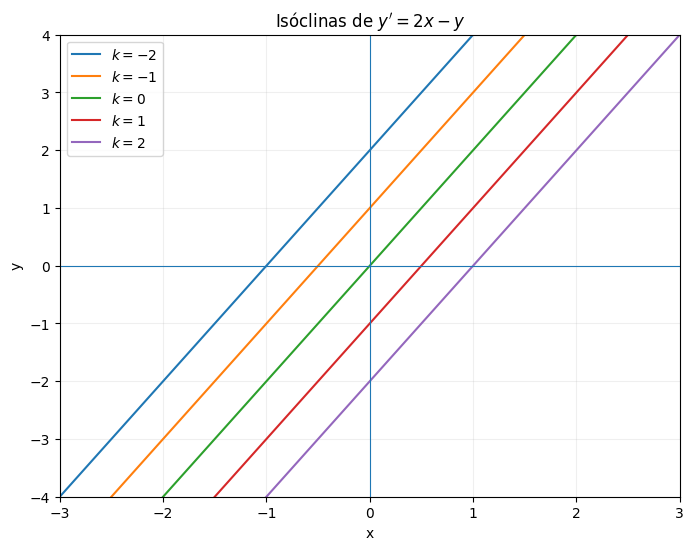

In [ ]:
x=np.linspace(-3,3,400)
plt.figure(figsize=(8,6))
for k in [-2,-1,0,1,2]:
    plt.plot(x,2*x-k,label=fr"$k={k}$")
plt.axhline(0,linewidth=.8); plt.axvline(0,linewidth=.8)
plt.xlim(-3,3); plt.ylim(-4,4)
plt.xlabel("x"); plt.ylabel("y")
plt.title(r"Isóclinas de $y'=2x-y$")
plt.grid(alpha=.2); plt.legend(); plt.show()

## 2.4 Isóclinas e campo de direções

Ao longo de cada isóclina, os segmentos do campo possuem todos a mesma inclinação.

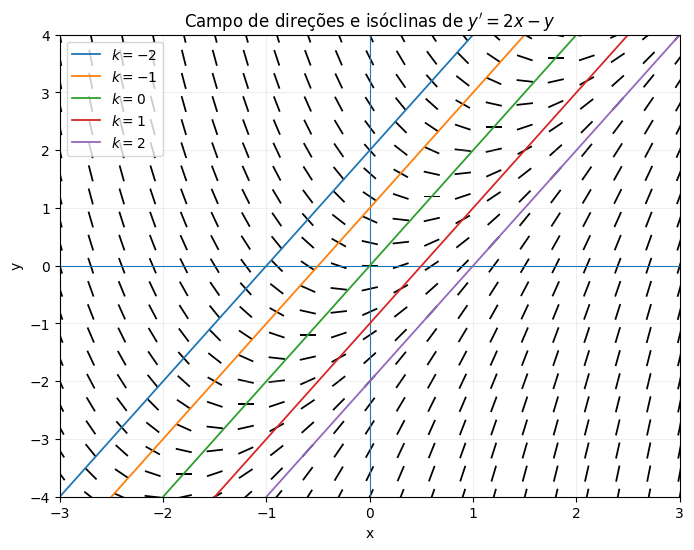

In [ ]:
campo_direcoes(lambda x,y:2*x-y,(-3,3),(-4,4))
x=np.linspace(-3,3,400)
for k in [-2,-1,0,1,2]:
    plt.plot(x,2*x-k,linewidth=1.3,label=fr"$k={k}$")
plt.title(r"Campo de direções e isóclinas de $y'=2x-y$")
plt.legend(); plt.show()

## 2.5 A isóclina nula

A isóclina $k=0$ é definida por
$$
f(x,y)=0.
$$
Sobre ela,
$$
y'=0,
$$
portanto as curvas integrais possuem **tangentes horizontais**.

Para $y'=2x-y$, a isóclina nula é
$$
\boxed{y=2x}.
$$
Além disso,
$$
y'>0\Longleftrightarrow y<2x,
$$
e
$$
y'<0\Longleftrightarrow y>2x.
$$
Assim, abaixo de $y=2x$ as soluções são crescentes; acima, decrescentes.

## 2.6 Máximos e mínimos

Se uma curva integral possui máximo ou mínimo em um ponto regular, então necessariamente
$$
y'=0.
$$
Logo, os possíveis extremos devem ocorrer sobre a isóclina nula.

A condição $y'=0$, porém, indica apenas tangente horizontal. Para distinguir máximo, mínimo ou outro comportamento, precisamos de informação adicional.

## 2.7 A segunda derivada sem resolver a EDO

De
$$
y'=f(x,y),
$$
pela regra da cadeia,
$$
y''=f_x+f_y\frac{dy}{dx}.
$$
Como $dy/dx=f(x,y)$,
$$
\boxed{y''=f_x+f_yf}.
$$
Portanto, podemos estudar a concavidade sem conhecer explicitamente as soluções.

Para $f(x,y)=2x-y$,
$$
f_x=2,\qquad f_y=-1,
$$
e
$$
\boxed{y''=2-2x+y}.
$$
Logo,
$$
y''=0\Longleftrightarrow y=2x-2.
$$
Acima dessa reta, $y''>0$; abaixo, $y''<0$.

## 2.8 Uma curva integral

Podemos nos perguntar: Existe alguma isóclina que é solução da equação
diferencial? Isto é, existe alguma isóclina (uma reta no nosso caso) em que o campo de direções aponta na direção da própria isóclina ?


A reta
$$
y=2x-k
$$
tem derivada $y'=2$. Substituindo-a na EDO,
$$ y' = 2 \, x - y $$
obtemos

$$
2=2x-(2x-k) \, ,
$$
isto é
$$
k= 2 \, .
$$

Portanto
$$
\boxed{y=2x-2}
$$
é simultaneamente isóclina ($k=2$) e curva integral.

Como $f(x,y)=2x-y$ e $f_y=-1$ são contínuas em todo o plano, vale unicidade em torno de qualquer ponto. Assim, nenhuma outra curva integral pode cruzar essa solução.

## 2.9 Construção qualitativa

Sem resolver $y'=2x-y$, já sabemos:

- as isóclinas são $y=2x-k$;
- sobre cada isóclina, a inclinação vale $k$;
- em $y=2x$, as tangentes são horizontais;
- acima de $y=2x$, as soluções decrescem;
- abaixo de $y=2x$, crescem;
- $y=2x-2$ é uma curva integral;
- acima de $y=2x-2$, $y''>0$;
- abaixo de $y=2x-2$, $y''<0$.

Essas informações permitem esboçar qualitativamente as curvas integrais.

## 2.10 Verificação com a solução exata

Para conferir nossa análise geométrica, podemos verificar que
$$
y=2x-2+Ce^{-x}
$$
satisfaz a EDO. Vamos desenhar algumas dessas curvas sobre o campo de direções.

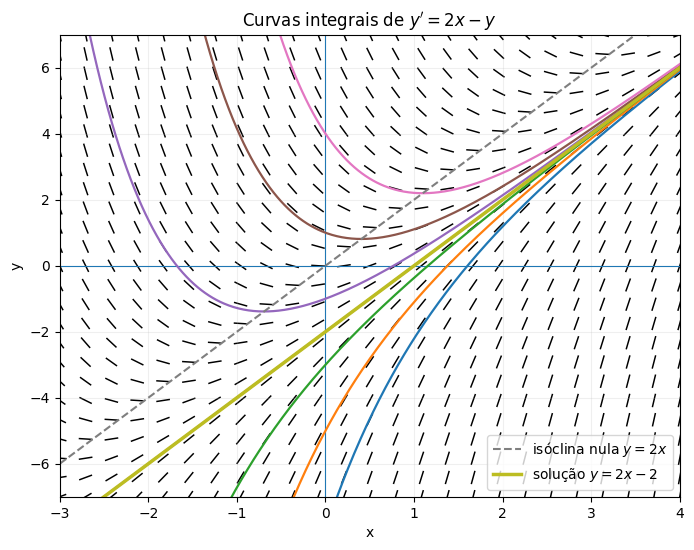

In [ ]:
x=np.linspace(-3,4,500)
campo_direcoes(lambda x,y:2*x-y,(-3,4),(-7,7),25,25)
for C in [-6,-3,-1,0,1,3,6]:
    plt.plot(x,2*x-2+C*np.exp(-x),linewidth=1.6)
plt.plot(x,2*x,linestyle="--",linewidth=1.5,label=r"isóclina nula $y=2x$")
plt.plot(x,2*x-2,linewidth=2.5,label=r"solução $y=2x-2$")
plt.title(r"Curvas integrais de $y'=2x-y$")
plt.legend(); plt.show()

## 2.11  Um exemplo em que as isóclinas são as próprias soluções

Considere
$$
y'=\frac{y}{x},\qquad x\neq0.
$$
As isóclinas são
$$
\frac{y}{x}=k,
$$
isto é,
$$
\boxed{y=kx}.
$$
Mas a derivada de $y=kx$ é $y'=k$ e $y/x=k$. Portanto, cada isóclina é também uma curva integral.

As retas parecem encontrar-se na origem, mas a equação $y'=y/x$ não está definida em $x=0$.

## 2.12 Exemplo: $$ y'=\sin(x+y) $$

As isóclinas satisfazem
$$
\sin(x+y)=k,\qquad -1\leq k\leq1.
$$
Para $k=0$,
$$
x+y=n\pi,
$$
logo
$$
\boxed{y=-x+n\pi},\qquad n\in\mathbb Z.
$$
Nessas retas, as curvas integrais têm tangentes horizontais.

Além disso,
$$
-1\leq\sin(x+y)\leq1
$$
implica
$$
-1\leq y'\leq1.
$$
A própria EDO, portanto, restringe globalmente as inclinações possíveis.

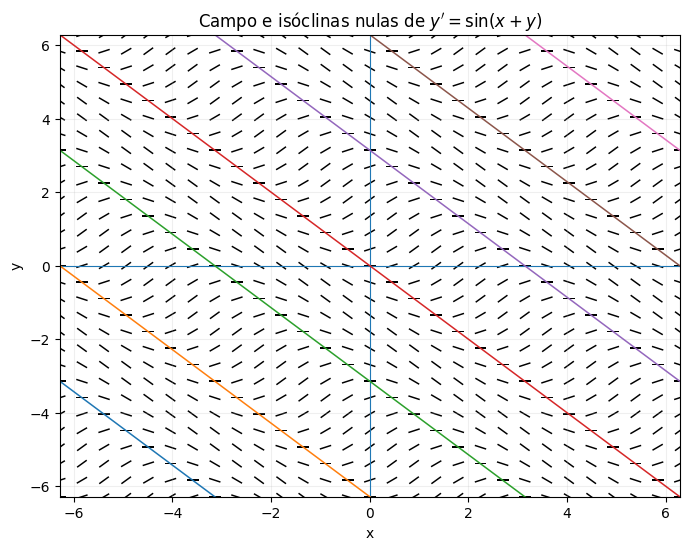

In [ ]:
campo_direcoes(lambda x,y:np.sin(x+y),
               (-2*np.pi,2*np.pi),(-2*np.pi,2*np.pi),29,29)
x=np.linspace(-2*np.pi,2*np.pi,500)
for n in range(-3,4):
    plt.plot(x,-x+n*np.pi,linewidth=1.1)
plt.title(r"Campo e isóclinas nulas de $y'=\sin(x+y)$")
plt.show()

## 2.13 Roteiro para o método das isóclinas

Dada
$$
y'=f(x,y),
$$
podemos proceder assim:

1. **Determine isóclinas:** resolva $f(x,y)=k$ para valores representativos de $k$.
2. **Determine a isóclina nula:** resolva $f(x,y)=0$.
3. **Estude o sinal de $y'$:** localize $f>0$ e $f<0$.
4. **Calcule a segunda derivada:**
$$
y''=f_x+f_yf.
$$
5. **Estude a concavidade:** localize $y''>0$ e $y''<0$.
6. **Procure curvas especiais:** verifique se alguma isóclina também é solução.
7. **Use existência e unicidade:** quando aplicável, soluções distintas não podem passar pelo mesmo ponto.


# Exercícios

### Exercício 1
Para
$$
y'=x+y,
$$
determine as isóclinas para $k=-2,-1,0,1,2$ e as regiões onde as soluções crescem ou decrescem.

### Exercício 2
Considere
$$
y'=x^2+y^2.
$$
Determine a isóclina nula e mostre que $y'\geq0$. O que isso implica sobre as curvas integrais?

### Exercício 3
Para
$$
y'=y-x,
$$
determine as isóclinas, a isóclina nula, as regiões de crescimento e decrescimento e as regiões de concavidade.

### Exercício 4
Considere
$$
y'=1-y^2.
$$
Determine as isóclinas. Encontre as retas horizontais que também são curvas integrais e determine onde as soluções crescem ou decrescem.

### Exercício 5
Para
$$
y'=\sin(x+y),
$$
mostre que $-1\leq y'\leq1$ e determine as isóclinas para $k=0,1,-1$.

### Exercício 6 — exploração computacional
Escolha uma das equações
$$
y'=x+y,\qquad y'=y-x^2,\qquad y'=\cos x-y.
$$
Usando `campo_direcoes`:

1. construa o campo de direções;
2. desenhe pelo menos cinco isóclinas;
3. identifique a isóclina nula;
4. determine visualmente as regiões de crescimento e decrescimento;
5. compare o gráfico com sua análise algébrica.